In [ ]:
import os
os.environ['KERAS_BACKEND'] = 'torch'
import keras
import torch
torch.cuda.is_available()
from keras.models import Sequential, Model
from keras.layers import Dense, Input, Flatten, Reshape, Rescaling, Conv2D, MaxPooling2D, Dropout, RandomFlip, RandomRotation, RandomCrop, RandomShear, RandomZoom, RandomContrast, RandomTranslation, RandomErasing
from keras.losses import SparseCategoricalCrossentropy
from keras.optimizers import Adam, RMSprop
from keras.metrics import Accuracy

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [4]:
print("Keras:", keras.__version__)
print("Backend:", keras.backend.backend())

x = keras.ops.ones((2, 32, 32, 3))

crop = keras.layers.RandomCrop(26, 26)

y = crop(x, training=True)

print(y.shape)

Keras: 3.15.1
Backend: torch
torch.Size([2, 26, 26, 3])


In [5]:
from keras.datasets import cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train, x_val, y_train, y_val = train_test_split(x_train,y_train, train_size= 0.8, random_state=1)


In [6]:
print(x_train.shape)
print(x_val.shape)
print(x_test.shape)

(40000, 32, 32, 3)
(10000, 32, 32, 3)
(10000, 32, 32, 3)


In [7]:
class_names= [
"airplane",
"automobile",
"bird",
"cat",
"deer",
"dog",
"frog",
"horse",
"ship",
"truck"
]

In [ ]:
kernel_size = (3,3)
strides = (1,1)

# x_train = x_train.float()
# x_val = x_val.float()

def build_model(activation: str = 'relu') -> Sequential:
  model = Sequential([
    Input(shape=(32,32,3)),

    RandomFlip('vertical'),
    # RandomTranslation(0.1, 0.1),
    RandomErasing
    # RandomZoom(0.2),
    # RandomCrop(26, 26),


    Rescaling(1./255), # place every value from 0 to 255 to between 0 and 1


    Conv2D(32,kernel_size,1,'same', activation=activation),
    Conv2D(32,kernel_size,1,'same', activation=activation),
    MaxPooling2D((2,2)),

    Conv2D(64,kernel_size,1,'same', activation=activation),
    Conv2D(64,kernel_size,1,'same', activation=activation),
    MaxPooling2D((2,2)),

    Conv2D(128,kernel_size,1,'same', activation=activation),
    Conv2D(128,kernel_size,1,'same', activation=activation),
    MaxPooling2D((2,2)),

    # Conv2D(256,kernel_size,1,'same', activation=activation),
    # Dropout(0.1),
    # Conv2D(256,kernel_size,1,'same', activation=activation),
    # Dropout(0.1),
    # MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(64, activation=activation),
    Dropout(0.1),
    Dense(64, activation=activation),
    Dropout(0.1),
    Dense(64, activation=activation),
    Dropout(0.1),
    Dense(64, activation=activation),
    Dropout(0.1),
    Dense(10, activation='softmax'), #10 categories
  
  ])


  model.compile(optimizer=Adam(), 
                loss=SparseCategoricalCrossentropy(),
                metrics=['accuracy'])

  return model


model = build_model()
model.summary()


  

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_translation              │ (None, 32, 32, 3)      │             0 │
│ (RandomTranslation)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,274 (1.65 MB)

 Trainable params: 431,274 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.fit(x_train, y_train, batch_size=256, epochs=30, validation_data=(x_val, y_val))

Epoch 1/30
142/157 ━━━━━━━━━━━━━━━━━━━━ 5s 397ms/step - accuracy: 0.1843 - loss: 2.0817

KeyboardInterrupt: 

In [ ]:
def plot_evaluation(history: dict, metrics: list[str] = ['accuracy']) -> None:
  metrics.append('loss')

  for metric in metrics:
    plt.Figure(figsize=(10,7))
    plt.lineplot(history[metric], label="train")
    plt.lineplot(history[f'val_{metric}'], label="val")
    plt.show()

plot_evaluation(model.history.history)

/tmp/ipykernel_25061/1918531191.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  sns.kdeplot(np.array(model.layers[-1].weights[0]).ravel())


<Axes: ylabel='Density'>

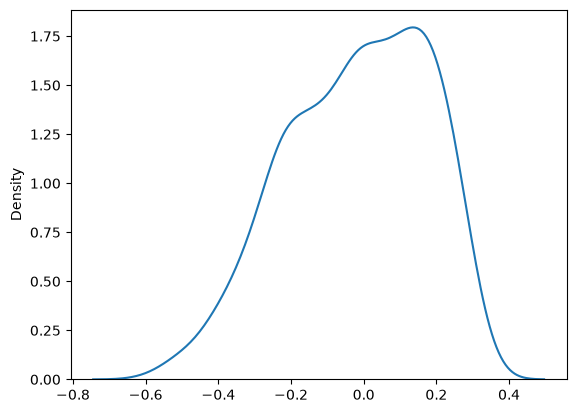

In [110]:
sns.kdeplot(np.array(model.layers[-1].weights[0]).ravel())

In [112]:
print(torch.cuda.is_available())

True
